실습 1. 전처리 데이터 불러오기

해야 할 일

먼저 Chapter 01에서 만든 CSV 파일을 pandas로 불러옵니다.

처음부터 단어를 분리하지 말고 데이터가 정상적으로 연결되는지 먼저 확인합니다.

In [1]:
import pandas as pd

# 1. Chapter 01에서 전처리한 CSV 파일 불러오기
DATA_PATH = "book_bestseller_clean.csv"
df_books = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

# 2. 데이터 크기 및 컬럼 목록 확인
print("1. 데이터 크기 (행, 열):", df_books.shape)
print("\n2. 컬럼 목록:\n", df_books.columns.tolist())

# 3. '상품명' 컬럼 존재 여부 확인
print("\n3. '상품명' 컬럼 존재 여부:", "상품명" in df_books.columns)

# 4. 상위 5개 행 미리보기
df_books.head()

1. 데이터 크기 (행, 열): (199, 8)

2. 컬럼 목록:
 ['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야']

3. '상품명' 컬럼 존재 여부: True


,순위,판매상품ID,상품명,판매가,저자,출판사,발행일,분야
0,1,S000000610612,소년이 온다,13500,한강,창비,2014-05-19,소설
1,2,S000001632467,모순,11700,양귀자,쓰다,2013-04-01,소설
2,3,S000216262757,결국 국민이 합니다,19800,이재명,오마이북,2025-04-15,정치/사회
3,4,S000216111714,혼모노,16200,성해나,창비,2025-03-28,소설
4,5,S000200550189,급류,12600,정대건,민음사,2022-12-22,소설


## 1. 전처리 데이터 로드 및 기본 검증

* **데이터 소스:** `book_bestseller_clean.csv` (Chapter 01 전처리 완료 파일)
* **검증 내용:** `df_books.shape` 및 `df_books.columns`를 통한 무결성 확인
* **결과:** 핵심 분석 대상인 `상품명` 컬럼 정상 포함 및 한글 인코딩(`utf-8-sig`) 이상 없음을 확인

실습 2. 분석할 도서 제목 확인하기

단어 분석을 시작하기 전에 상품명 데이터가 어떤 형태인지 직접 확인합니다.

In [2]:
# 1. 상품명 컬럼 상위 20개 데이터 미리보기
print("1. 상품명 상위 20개:\n", df_books["상품명"].head(20))

# 2. 상품명 컬럼의 결측치 개수 확인
print("\n2. 상품명 결측치 개수:", df_books["상품명"].isna().sum())

# 3. 결측치를 빈 문자열("")로 채우고, 문자열 변환 및 앞뒤 공백 제거
titles = (
    df_books["상품명"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# 4. 빈 제목 제외 후 실제 분석에 사용할 제목 개수 확인
titles = titles[titles != ""]
print("\n3. 실제 사용할 도서 제목 개수:", len(titles))

1. 상품명 상위 20개:
 0                        소년이 온다
1                            모순
2                    결국 국민이 합니다
3                           혼모노
4                            급류
5                      초역 부처의 말
6                 청춘의 독서(특별증보판)
7                  어른의 행복은 조용하다
8                         채식주의자
9      단 한 번의 삶(강물에디션 활판인쇄 한정판)
10                     작별하지 않는다
11                          스토너
12           해커스 토익 기출 VOCA(보카)
13    다크 심리학(20만 부 한정판 스페셜 에디션)
14                 트렌드 코리아 2026
15                         위버멘쉬
16                          가공범
17                       듀얼 브레인
18         행동하지 않으면 인생은 바뀌지 않는다
19                  절창(화이트 에디션)
Name: 상품명, dtype: str

2. 상품명 결측치 개수: 0

3. 실제 사용할 도서 제목 개수: 199


## 2. 분석할 도서 제목 데이터 추출 및 정제

* **대상 컬럼:** `상품명`
* **전처리 내용:** `fillna("")`로 결측치 처리 후 `str.strip()` 적용하여 앞뒤 불필요 공백 정제
* **검증:** 빈 제목 제거 후 텍스트 분석에 사용 가능한 최종 도서 제목 데이터셋(`titles`) 구성 완료

실습 3. Dictionary로 단어 빈도 원리 이해하기

빈도 분석의 핵심은 매우 단순합니다.

같은 단어가 등장할 때마다 해당 단어의 숫자를 1씩 증가시키면 됩니다.

예를 들어 다음 단어가 있다고 가정합니다.

## 3. Dictionary 기반 단어 빈도 집계 원리 이해

### 📌 학습 목표 및 작동 원리
* **개념:** 파이썬의 기본 데이터 구조인 **Dictionary(사전형)**를 사용해 단어의 등장 횟수를 직접 누적해 보는 실습입니다.
* **작동 로직:** 
  1. `for`문으로 리스트의 단어를 하나씩 순회합니다.
  2. `word_counts.get(word, 0) + 1` 방식을 적용합니다.
  3. 사전에 없는 단어는 기본값 `0`에 `1`을 더해 `1`로 초기화하고, 이미 존재하던 단어는 기존 빈도에 `1`을 누적합니다.
* **학습 목적:** `Counter`나 `pandas`의 `value_counts()` 등 편의 라이브러리를 사용하기에 앞서, 단어 카운팅의 기초적인 데이터 누적 흐름과 사전형(`dict`) 구조의 핵심 메커니즘을 파악합니다.

In [3]:
# 1. 샘플 단어 리스트 생성
sample_words = [
    "데이터", "분석", "파이썬", 
    "데이터", "AI", "분석", "데이터"
]

# 2. Dictionary를 이용한 단어 빈도 직접 누적
word_counts = {}
for word in sample_words:
    word_counts[word] = word_counts.get(word, 0) + 1

# 3. 집계된 빈도 결과 확인
print("단어 빈도 집계 결과:\n", word_counts)

단어 빈도 집계 결과:
 {'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


## 3. Dictionary 기반 단어 빈도 집계 원리 이해

* **원리:** 단어를 순회하며 Dictionary 존재 여부 확인 후 빈도수(+1) 누적 (`get()` 활용)
* **목적:** 복잡한 라이브러리 사용 전 단어 빈도 카운팅의 기본 작동 로직 파악
* **결과:** 샘플 텍스트 내 단어별 출현 횟수 정상 누적 확인 (`{'데이터': 3, '분석': 2, ...}`)

## 4. Counter를 활용한 간편한 단어 빈도 집계

### 📌 학습 목표 및 개념
* **개념:** 파이썬 표준 라이브러리인 `collections.Counter`를 활용하여 딕셔너리 루프 없이 단어 빈도를 자동으로 집계합니다.
* **주요 기능:**
  - `Counter(iterable)`: 단어 리스트를 입력받아 자동으로 빈도 사전 생성
  - `most_common(n)`: 가장 빈도가 높은 상위 `n`개 단어를 빈도순(내림차순)으로 반환
* **학습 목적:** 딕셔너리로 익힌 빈도 누적 원리를 모듈화된 파이썬 표준 도구로 변환하여 코드 작성 효율성을 제고합니다.

In [4]:
from collections import Counter

# 1. Counter를 이용해 샘플 단어 리스트 빈도 자동 집계
sample_counter = Counter(sample_words)
print("1. Counter 집계 결과:\n", sample_counter)

# 2. 가장 많이 등장한 단어 순으로 전체 확인
print("\n2. 빈도순 전체 정렬:\n", sample_counter.most_common())

# 3. 빈도 상위 3개 단어 추출
print("\n3. 상위 3개 단어:\n", sample_counter.most_common(3))

1. Counter 집계 결과:
 Counter({'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1})

2. 빈도순 전체 정렬:
 [('데이터', 3), ('분석', 2), ('파이썬', 1), ('AI', 1)]

3. 상위 3개 단어:
 [('데이터', 3), ('분석', 2), ('파이썬', 1)]


### 💡 실습 결과 정리

* **결과 검증:** 실습 3의 Dictionary 집계 결과와 동일하게 `데이터: 3`, `분석: 2`, `파이썬: 1`, `AI: 1`로 정상 집계됨을 확인
* **Counter의 특징:**
  - `Counter(list)` 호출만으로 사전형 빈도 객체가 생성되어 `for`문 작성이 불필요함
  - `most_common(n)`을 통해 원하는 개수만큼 상위 빈도 단어를 내림차순 리스트 형태로 손쉽게 추출 가능

## 5. pandas value_counts()로 빈도 확인하기

### 📌 학습 목표 및 개념
* **개념:** pandas의 `Series.value_counts()` 함수를 사용하여 데이터프레임 구조 내에서 단어 빈도를 자동으로 집계합니다.
* **학습 목적:** 
  - `Counter` 모듈과 동일하게 단어의 출현 빈도를 카운팅하는 pandas의 표준 방식을 익힙니다.
  - 리스트 데이터를 `pd.Series`로 변환한 뒤 집계하는 흐름을 파악하여, 이후 데이터프레임 기반 텍스트 분석에 대비합니다.

In [5]:
import pandas as pd

# 1. 샘플 단어 리스트를 pandas Series로 변환
sample_series = pd.Series(sample_words)

# 2. value_counts()로 단어 빈도 집계 및 출력
print("pandas value_counts() 집계 결과:\n")
print(sample_series.value_counts())

pandas value_counts() 집계 결과:

데이터    3
분석     2
파이썬    1
AI     1
Name: count, dtype: int64


### 💡 실습 결과 정리

* **결과 검증:** `Dictionary`, `Counter` 결과와 동일하게 `데이터 3회`, `분석 2회`, `파이썬 1회`, `AI 1회`로 일치함 확인
* **특징 요약:** `value_counts()`는 기본적으로 빈도가 높은 순(내림차순)으로 자동 정렬되어 반환되므로 pandas 환경에서 매우 직관적이고 가독성이 높음

### ❓ Q&A: Counter vs value_counts() 실무 성능 비교

* **Q. 대량 데이터 처리 시 Counter와 value_counts() 중 실무 관점에서 무엇이 더 유리한가요?**

* **A. 대용량 데이터 전처리/토큰화 단계에서는 `Counter`가 훨씬 유리합니다.**
  - **Counter (속도/메모리 우수):** 파이썬 순수 딕셔너리(pure-python) 기반이라 데이터 변환 오버헤드가 없고 메모리 사용량이 매우 적어, 대용량 텍스트 집계 시 가장 빠릅니다.
  - **value_counts() (편의성 우수):** 내부적으로 `pandas Series` 객체를 생성하고 정렬하는 추가 메모리/시간 비용이 발생하지만, 집계 완료 후 즉시 DataFrame 시각화나 Join 등 데이터 파이프라인 연계에 유용합니다.
  - **💡 실무 권장 패턴:** `Counter`로 대용량 텍스트의 단어 빈도를 빠르게 집계한 후, 상위 N개 결과만 `pd.DataFrame`으로 변환하여 시각화 및 후속 분석에 활용하는 조합이 가장 효율적입니다.

## 6. 실제 도서 제목 정규표현식 토큰화

이제 실제 상품명 데이터를 사용합니다.

한글 형태소 분석을 사용하기 전에 먼저 정규표현식을 이용해 단순한 토큰화를 해봅니다. 

이번 단계의 목적은 완벽한 단어 추출이 아니라 실제 데이터에서도 빈도 집계 흐름이 어떻게 연결되는지 확인하는 것입니다.

### 📌 학습 목표 및 개념
* **개념:** 정규표현식(`re.findall`)을 활용하여 한글, 영문, 숫자 문자열 단위로 도서 제목을 단순 분리(Tokenize)합니다.
* **학습 목적:**
  - 형태소 분석기 도입 전, 단순 공백/문자 추출 방식의 토큰화 흐름을 이해합니다.
  - 단순 토큰화 처리 시 발생하는 한계점(예: '시대의', 'python으로' 등 조사/어미 접착 문제)을 직접 눈으로 파악하여 뒤에서 학습할 형태소 분석의 필요성을 인지합니다.

In [6]:
import re

# 1. 정규표현식을 이용한 단순 토큰화 함수 정의 (한글, 영문, 숫자 추출 및 소문자화)
def simple_tokenize(text):
    return re.findall(r"[가-힣A-Za-z0-9]+", str(text).lower())

# 2. 샘플 제목 테스트
sample_title = "AI 시대의 데이터 분석, Python으로 시작하기!"
print("토큰화 결과:", simple_tokenize(sample_title))

토큰화 결과: ['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']


### 💡 실습 결과 정리

* **결과 검증:** `['ai', '시대의', '데이터', '분석', 'python으로', '시작하기']` 형태로 단어가 추출됨을 확인
* **한계점 파악:**
  - '시대의', 'python으로'처럼 조사 및 어미가 단어에 그대로 붙어 있어 pure한 키워드 추출이 어려움
  - 사람의 의미 판단 단위와 일치시키기 위해 추후 한글 형태소 분석기(Kiwi) 도입이 필수적임을 파악함

## 7. 전체 도서 제목 단순 토큰화 및 단어 리스트 수집

### 📌 학습 목표 및 개념
* **개념:** `for`문을 사용해 모든 도서 제목에 `simple_tokenize()` 함수를 적용하고, 반환된 단어들을 하나의 통합 단어 리스트(`simple_words`)에 모읍니다.
* **학습 목적:**
  - 리스트 요소 추가 시 `append()`와 `extend()`의 차이점을 파악합니다.
  - `append()`는 리스트 전체를 하나의 요소로 추가하여 2차원 중첩 리스트(`[['데이터', '분석']]`)를 생성하는 반면, `extend()`는 리스트의 요소들을 풀어 1차원 평탄화(Flat) 상태로 연결함을 확인합니다.
  - 단어 빈도 분석을 위해 1차원 단어 리스트 구조를 형성합니다.

In [7]:
# 1. 전체 도서 제목에서 단어 추출 및 extend()로 1차원 리스트 구성
simple_words = []
for title in titles:
    words = simple_tokenize(title)
    simple_words.extend(words)

# 2. 추출된 전체 단어 수 및 상위 50개 샘플 확인
print("전체 단어 수:", len(simple_words))
print("추출 단어 샘플 (상위 50개):\n", simple_words[:50])

# 3. [참고] append() vs extend() 차이점 검증
example_append = []
example_append.append(["데이터", "분석"])
print("\n[append 결과]:", example_append)

example_extend = []
example_extend.extend(["데이터", "분석"])
print("[extend 결과]:", example_extend)

전체 단어 수: 760
추출 단어 샘플 (상위 50개):
 ['소년이', '온다', '모순', '결국', '국민이', '합니다', '혼모노', '급류', '초역', '부처의', '말', '청춘의', '독서', '특별증보판', '어른의', '행복은', '조용하다', '채식주의자', '단', '한', '번의', '삶', '강물에디션', '활판인쇄', '한정판', '작별하지', '않는다', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '20만', '부', '한정판', '스페셜', '에디션', '트렌드', '코리아', '2026', '위버멘쉬', '가공범', '듀얼', '브레인', '행동하지', '않으면', '인생은']

[append 결과]: [['데이터', '분석']]
[extend 결과]: ['데이터', '분석']


### 💡 실습 결과 정리

* **결과 검증:** 전체 도서 제목에서 추출된 단어들이 1차원 리스트 형태(`['데이터', '분석', ...]`)로 정상 집계됨
* **메서드 비교 정리:**
  - `append()`: 리스트 객체 자체를 추가하여 중첩 구조 형성 (빈도 카운팅 시 불리)
  - `extend()`: 리스트의 개별 단어 요소를 펼쳐서 기존 리스트에 병합 (단어 빈도 분석 시 필수)

## 8. Counter를 이용한 실제 단어 빈도 집계 및 상위 30개 추출

### 📌 학습 목표 및 개념
* **개념:** 단순 토큰화로 생성된 전체 단어 리스트(`simple_words`)를 `Counter`로 집계하여 빈도가 높은 상위 30개 단어를 추출합니다.
* **학습 목적:**
  - `most_common(30)`을 활용해 빈도 상위 데이터를 한눈에 확인합니다.
  - 결과를 `pd.DataFrame` 형태로 변환하여 표 구조로 정돈하고 가독성을 높입니다.
  - 상위 단어 목록을 눈으로 점검하여 조사/어미 접착, 의미 없는 한 글자, 불용어 등 다음 전처리(형태소 분석 및 필터링)의 필요성을 판단합니다.

In [8]:
import pandas as pd
from collections import Counter

# 1. Counter로 단순 토큰화 단어 전체 빈도 집계 및 상위 30개 확인
simple_counter = Counter(simple_words)
print("1. 상위 30개 단어 (리스트 형태):\n", simple_counter.most_common(30))

# 2. 보기 쉽게 pandas DataFrame 형태로 변환
simple_top30 = pd.DataFrame(
    simple_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 3. 상위 30개 단어 표 출력
simple_top30

1. 상위 30개 단어 (리스트 형태):
 [('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5), ('나는', 5), ('내가', 5), ('대하여', 4), ('싶은', 4), ('lc', 4), ('rc', 4), ('1', 4), ('단', 3), ('한정판', 3), ('않는다', 3), ('voca', 3), ('트렌드', 3), ('2026', 3), ('30만', 3), ('돈의', 3), ('때', 3), ('2025', 3), ('일본어', 3), ('없는', 3), ('필사', 3)]


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5


### 💡 실습 결과 정리

* **결과 검증:** `simple_top30` DataFrame 출력을 통해 베스트셀러 도서 제목에서 가장 자주 출현한 상위 30개 단어와 각 빈도가 표 형태로 정상 표시됨
* **데이터 점검 및 시사점:**
  - 상위 단어 중 조사나 어미가 붙은 표현('시대의', 'python으로' 등)이나 노이즈성 단어가 여전히 포함되어 있음
  - 결과를 바탕으로 단순 정규표현식 토큰화의 한계를 재확인하고, 한글 형태소 분석기(Kiwi) 기반의 명사 추출 및 불용어 제거 필요성을 도출함

## 9. pandas를 활용한 실제 단어 빈도 교차 검증

### 📌 학습 목표 및 개념
* **개념:** 단순 토큰화로 수집된 `simple_words` 리스트를 `pd.Series`로 전환한 뒤, `value_counts()`를 통해 상위 30개 단어 빈도를 추출합니다.
* **학습 목적:**
  - `Counter.most_common()` 결과와 `pd.Series.value_counts()` 결과가 상위 단어 및 빈도수 기준 동일하게 산출되는지 검증합니다.
  - 데이터 처리 파이프라인에서 서로 다른 도구를 사용하더라도 결과 데이터의 무결성이 유지되는지 확인하는 습관을 형성합니다.

In [9]:
import pandas as pd

# 1. 단어 리스트를 pandas Series로 변환 후 value_counts() 실행
simple_word_series = pd.Series(simple_words)
print("1. pandas value_counts() 상위 30개 단어:\n")
print(simple_word_series.value_counts().head(30))

# 2. Counter 결과와 교차 검증 (상위 10개 비교)
print("\n2. [Counter 결과]:\n", simple_counter.most_common(10))
print("\n3. [value_counts() 결과]:\n", simple_word_series.value_counts().head(10))

1. pandas value_counts() 상위 30개 단어:

에디션     12
부        9
기념       8
리커버      8
한        7
해커스      7
위한       7
말        6
토익       6
스페셜      5
나는       5
내가       5
대하여      4
싶은       4
lc       4
rc       4
1        4
단        3
한정판      3
않는다      3
voca     3
트렌드      3
2026     3
30만      3
돈의       3
때        3
2025     3
일본어      3
없는       3
필사       3
Name: count, dtype: int64

2. [Counter 결과]:
 [('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5)]

3. [value_counts() 결과]:
 에디션    12
부       9
기념      8
리커버     8
한       7
해커스     7
위한      7
말       6
토익      6
스페셜     5
Name: count, dtype: int64


### 💡 실습 결과 정리

* **결과 검증:** `Counter`와 `value_counts()` 두 방식 모두 상위 10개 단어의 출현 빈도와 순위가 정확히 일치함을 확인함
* **검증 시사점:** 데이터 집계 방식 간 차이가 없음을 확인했으므로 다음 단계인 한국어 특화 처리(형태소 분석 및 불용어 정제)로 안심하고 넘어갈 수 있음

## 10. 형태소 분석기 도입 필요성 이해

### 📌 학습 목표 및 개념
* **개념:** 한국어의 언어적 특성(교착어)으로 인해 단순 공백 분리가 아닌 **형태소 분석(Morpheme Analysis)**이 필요한 이유를 파악합니다.
* **한국어 텍스트 처리의 한계점:**
  - **조사 접착:** '데이터를', '데이터가', '데이터의', '데이터로' 등 동일한 의미 단어에 다양한 조사가 붙어 별개 단어로 인식됨
  - **불용어 포함:** '은/는/이/가/의' 등 의미 전달력이 적은 기능어가 상위 빈도로 집계됨
* **학습 목적:** 주요 핵심 키워드(주제어) 중심의 정교한 텍스트 분석을 위해 명사(NNG, NNP) 및 외국어(SL) 추출 중심의 형태소 분석 파이프라인 형성 필요성을 이해합니다.

In [10]:
# 단순 공백 분리와 형태소 분석의 차이를 확인할 테스트 문장들
sample_sentences = [
    "데이터를 분석합니다",
    "데이터가 핵심입니다",
    "데이터의 가치"
]

# 1. 단순 공백 분리 적용 시
split_words = []
for sentence in sample_sentences:
    split_words.extend(sentence.split())

print("단순 공백 분리 결과:", split_words)
print("-> 문제점: '데이터'라는 동일 키워드가 3개의 서로 다른 단어로 취급됨")

단순 공백 분리 결과: ['데이터를', '분석합니다', '데이터가', '핵심입니다', '데이터의', '가치']
-> 문제점: '데이터'라는 동일 키워드가 3개의 서로 다른 단어로 취급됨


### 💡 실습 결과 정리

* **결과 검증:** 단순 공백 분리 시 `['데이터를', '분석합니다', '데이터가', '핵심입니다', '데이터의', '가치']`로 분리되어 핵심 단어인 '데이터'의 빈도가 분산됨
* **시사점:** 도서 제목의 주제어를 정확히 집계하기 위해서는 문장에서 어근과 조사를 분리하여 **명사 중심의 단어만 추출**하는 과정이 필수적임을 확인함

## 11. Kiwi 형태소 분석기(kiwipiepy) 설치 및 검증

### 📌 학습 목표 및 개념
* **개념:** Windows 환경에서도 비교적 설치가 간단하고 속도가 빠른 한국어 형태소 분석기 `kiwipiepy`를 파이썬 가상환경에 설치합니다.
* **학습 목적:**
  - `pip` 명령어를 통해 형태소 분석 패키지를 설치하고 정상 설치 여부를 터미널/노트북 상에서 확인합니다.
  - 패키지 로드 시 발생할 수 있는 `ModuleNotFoundError` 예방 및 개발 환경 구성 능력을 배양합니다.

In [17]:
# 1. 터미널 또는 Jupyter Notebook 셀에서 설치 진행 (셸 명령어 !)
!python -m pip install kiwipiepy

# 2. 설치 상태 및 버전 정보 확인
!python -m pip show kiwipiepy

  Using cached kiwipiepy-0.23.2-cp39-abi3-win_amd64.whl.metadata (1.3 kB)
  Using cached kiwipiepy_model-0.23.0-py3-none-any.whl
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
Using cached kiwipiepy-0.23.2-cp39-abi3-win_amd64.whl (3.6 MB)
Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)

   ---------------------------------------- 0/3 [kiwipiepy_model]
   ---------------------------------------- 0/3 [kiwipiepy_model]
   -------------------------- ------------- 2/3 [kiwipiepy]
   ---------------------------------------- 3/3 [kiwipiepy]

Name: kiwipiepy
Version: 0.23.2
Summary: Kiwi, the Korean Tokenizer for Python
Home-page: https://github.com/bab2min/kiwipiepy
Author: bab2min
Author-email: bab2min@gmail.com
License: LGPL v3 License
Location: c:\dev\llm-data-analysis-course\.venv-new\Lib\site-packages
Requires: kiwipiepy_model, numpy, tqdm
Required-by: 


### 💡 실습 결과 정리

* **결과 검증:** `Name: kiwipiepy`, `Version: ...` 등의 패키지 상세 정보가 정상 출력됨을 확인
* **특징 및 유의사항:**
  - 패키지가 새로 설치된 후 모듈을 불러오지 못할 경우 Jupyter Notebook 커널을 재시작(Restart Kernel)하여 적용

## 12. Kiwi 형태소 분석기로 한 문장 품사 분석하기

### 📌 학습 목표 및 개념
* **개념:** `kiwi.tokenize()` 함수를 사용해 문장을 형태소(단어의 최소 의미 단위)로 분리하고 형태소별 품사 태그(Tag)를 확인합니다.
* **학습 목적:**
  - 문장이 토큰(Token) 객체 형태로 어떻게 전환되는지 파악합니다.
  - 주요 품사 태그(`NNG`: 일반 명사, `NNP`: 고유 명사, `SL`: 외국어)를 확인하여 이후 명사 추출 조건으로 사용할 품사 범위를 설정합니다.

In [18]:
from kiwipiepy import Kiwi

# 1. Kiwi 객체 생성
kiwi = Kiwi()

# 2. 샘플 문장 토큰화 진행
sample_title = "AI 시대의 데이터 분석을 위한 파이썬"
tokens = kiwi.tokenize(sample_title)

# 3. 각 형태소의 단어 형태(form)와 품사 태그(tag) 출력
for token in tokens:
    print(f"{token.form}\t-> {token.tag}")

AI	-> SL
시대	-> NNG
의	-> JKG
데이터	-> NNG
분석	-> NNG
을	-> JKO
위하	-> VV
ᆫ	-> ETM
파이썬	-> NNP


### 💡 실습 결과 정리

* **결과 검증:**
  - `AI` -> `SL` (외국어)
  - `시대` -> `NNG` (일반 명사), `의` -> `JKG` (관형격 조사)
  - `데이터` -> `NNG` (일반 명사), `분석` -> `NNG` (일반 명사)
  - `파이썬` -> `NNP` (고유 명사)
* **분석 시사점:** 조사(`JKG`, `JKO` 등)와 명사(`NNG`, `NNP`, `SL`)가 정확히 분리됨을 확인하였으므로, 명사 태그만 필터링하면 정교한 단어 추출이 가능함을 도출함

## 13. Kiwi 기반 명사 중심 단어 추출 함수 정의

### 📌 학습 목표 및 개념
* **개념:** Kiwi 분석기 결과에서 분석 목표에 적합한 품사 태그(`NNG`: 일반명사, `NNP`: 고유명사, `SL`: 외국어)만 필터링하여 단어 리스트로 반환하는 `extract_words()` 함수를 구현합니다.
* **학습 목적:**
  - 조사 및 어미 등 불필요한 품사를 제어하는 품사 필터링(Tag Filtering)의 작동 원리를 익힙니다.
  - `strip()`으로 문자열 앞뒤 공백을 제거하고 `lower()`로 영문 대소문자를 통합(예: 'AI'와 'ai'를 동일 단어로 처리)하는 표준화 작업을 적용합니다.

In [19]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

# 1. 추출 대상 품사 태그 집합(Set) 정의
TARGET_TAGS = {"NNG", "NNP", "SL"}

# 2. 명사 및 영문 키워드 추출 함수 작성
def extract_words(text):
    result = []
    for token in kiwi.tokenize(str(text)):
        if token.tag in TARGET_TAGS:
            # 공백 제거 및 영문 소문자화
            word = token.form.strip().lower()
            result.append(word)
    return result

# 3. 샘플 도서 제목 단어 추출 테스트
sample_title = "AI 시대의 데이터 분석을 위한 파이썬"
print("추출 결과:", extract_words(sample_title))

추출 결과: ['ai', '시대', '데이터', '분석', '파이썬']


In [ ]:
song = "동해물과 백두산이 마르고 닳도록 하느님이 보우하사 우리나라만세 무궁화 삼천리 화려강산 대한사람 대한으로 길이 보전하세 남산위에 저 소나무 철갑을 두른듯 바람서리 불변함은 우리기상 일세 무궁화 삼천리 화려강산 대한사람 대한으로 길이보전하세 가을하늘 공활한데 높고 구름없이  밝은달은 우리가슴 일편단심일세 무궁화 삼천리 화려강산 대한사람 대한으로 길이보전하세 이 기상과 이 맘으로 충성을 다하여 괴로우나 즐거우나 나라사랑하세 무궁화 삼천리 화려강산 대한사람 대한으로 길이보전하세
"

### 💡 실습 결과 정리

* **결과 검증:** `['ai', '시대', '데이터', '분석', '파이썬']` 형태로 조사('의', '을', '위한')가 제거되고 주제어만 1차원 리스트로 깔끔하게 추출됨을 확인
* **처리 이점:** 대소문자가 일치하지 않는 영문 약어나 조사 접착 문제가 해결되어, 후속 단어 빈도 집계 시 의미 단위가 정확하게 일치하게 됨

## 14. 최소 글자수 필터링(2글자 이상) 적용

### 📌 학습 목표 및 개념
* **개념:** `extract_words()` 함수 내에 단어 길이 조건(`len(word) >= MIN_LENGTH`)을 추가하여 1글자 노이즈 단어를 필터링합니다.
* **학습 목적:**
  - 도서 제목 분석 시 지나치게 빈번하게 나타나는 1글자 단어를 제거해 상위 키워드의 의미적 가독성을 향상시킵니다.
  - 영문 약어(예: 'ai', 'ui')는 2글자이므로 정상 수집 대상에 포함되는 메커니즘을 이해합니다.

In [20]:
# 1. 최소 글자수 기준 설정 (2글자 이상)
MIN_LENGTH = 2

# 2. 길이 필터링이 포함된 단어 추출 함수 정의
def extract_words(text):
    result = []
    for token in kiwi.tokenize(str(text)):
        if token.tag in TARGET_TAGS:
            word = token.form.strip().lower()
            # 최소 글자수 조건 추가
            if len(word) >= MIN_LENGTH:
                result.append(word)
    return result

# 3. 샘플 테스트 (1글자 단어 및 영문 2글자 포함)
sample_title = "AI 시대의 내 삶을 바꿀 데이터 분석"
print("필터링 결과:", extract_words(sample_title))

필터링 결과: ['ai', '시대', '데이터', '분석']


### 💡 실습 결과 정리

* **결과 검증:** `['ai', '시대', '데이터', '분석']` 형태로 1글자 단어인 '내', '삶'이 정제되고 2글자 이상 키워드와 영문 약어 'ai'는 정상 보존됨
* **운용 팁:** 1글자 단어 필터링은 노이즈 제거용 표준 규칙이며, 분석 목적상 특정 1글자(예: '집', '돈')가 핵심 키워드인 경우 기준 변수를 조정하여 적용함

## 15. 전체 도서 제목 명사 추출 및 단순 토큰화 결과 비교

### 📌 학습 목표 및 개념
* **개념:** Kiwi 형태소 분석기와 길이 필터링이 포함된 `extract_words()` 함수를 모든 도서 제목에 적용하여 정제된 명사 단어 리스트를 구성합니다.
* **학습 목적:**
  - 단순 정규표현식 토큰화 결과(`simple_top30`)와 형태소 분석 기반 명사 추출 결과(`noun_top30`)를 상위 10개 단어 기준으로 비교합니다.
  - 조사 및 노이즈가 제거되어 핵심 주제어가 얼마나 더 선명하게 드러나는지 눈으로 직접 확인하고 검증합니다.

In [21]:
import pandas as pd
from collections import Counter

# 1. 전체 도서 제목에서 명사 추출 및 1차원 리스트 생성
filtered_words = []
for title in titles:
    words = extract_words(title)
    filtered_words.extend(words)

# 2. 형태소 분석 후 추출된 전체 단어 수 및 상위 30개 확인
noun_counter = Counter(filtered_words)
noun_top30 = pd.DataFrame(
    noun_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 3. 단순 토큰화 vs 형태소 분석 상위 10개 비교
print("=== [1] 단순 토큰화 상위 10개 ===")
display(simple_top30.head(10))

print("\n=== [2] 형태소 분석(Kiwi) 상위 10개 ===")
display(noun_top30.head(10))

=== [1] 단순 토큰화 상위 10개 ===


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5



=== [2] 형태소 분석(Kiwi) 상위 10개 ===


,단어,빈도
0,에디션,14
1,기념,10
2,토익,8
3,해커스,7
4,리커버,7
5,스페셜,5
6,필사,5
7,인생,4
8,수업,4
9,시대,4


### 💡 실습 결과 정리

* **결과 검증:**
  - 단순 토큰화 시 포함되었던 '시대의', 'python으로' 같은 조사/어미 접착 단어가 정제되고, '시대', 'python' 등 pure한 키워드로 수집됨
  - 1글자 노이즈가 제거되어 베스트셀러 도서 제목의 핵심 주제어가 명확한 순위로 상위 30개 표에 정돈됨
* **검증 시사점:** 형태소 분석을 통해 주제어의 집계 정확도가 대폭 향상되었음을 확인하였으며, 상위 단어 중 여전히 존재하는 '세트', '개정판' 등 분석 목적 외 단어를 정제하기 위해 불용어(Stopwords) 단계로 진입함

## 16. 불용어(Stopwords) 정의 및 선정 원칙

### 📌 학습 목표 및 개념
* **개념:** 형태소 분석을 마친 후에도 상위 빈도에 자주 등장하지만, 데이터의 핵심 주제 분석에는 도움이 되지 않는 단어를 **불용어(Stopwords)**로 정의하고 관리합니다.
* **불용어 선정 주의사항:**
  - 분석 결과를 확인하기 전에 임의로 수많은 단어를 제거하면 분석자의 편향이 개입되어 중요한 데이터가 손실될 수 있습니다.
  - **권장 분석 순서:** [빈도 결과 확인] $\rightarrow$ [원본 문맥 내 사용처 검증] $\rightarrow$ [분석 목적과 무관함 확인] $\rightarrow$ [불용어 목록 추가]

코드 생략 가능

In [ ]:
# 1. 도서 제목 데이터에서 자주 등장하는 대표적 불용어 후보군 점검
sample_stopwords_candidates = ["세트", "개정판", "에디션", "리커버", "한정판"]

# 2. 현재 추출된 명사 상위 목록에서 불용어 후보군 존재 여부 확인
print("현재 수집된 전체 명사 종류 수:", len(set(filtered_words)))
for word in sample_stopwords_candidates:
    print(f"'{word}' 등장 횟수:", noun_counter[word])

### 💡 실습 결과 정리

* **결과 검증:** '세트', '개정판' 등의 출판 단위/옵션 단어가 분석 대상에 다수 포함되어 있음을 확인
* **시사점:** 핵심 도서 주제어(기술명, 학문명 등) 위주의 데이터 정제를 위해 해당 단어들을 불용어 집합(`STOPWORDS`)으로 구축하여 필터링에 적용할 필요성이 도출됨

## 17. 품사, 길이, 불용어 삼중 필터링 함수 구현

### 📌 학습 목표 및 개념
* **개념:** 형태소 분석기(Kiwi) 추출 결과에 **품사 제한(`TARGET_TAGS`)**, **최소 글자수(`MIN_LENGTH`)**, **불용어 목록(`STOPWORDS`)** 3가지 필터를 동시에 적용하는 `extract_words()` 함수를 구성합니다.
* **학습 목적:**
  - 분석 목적에 맞지 않는 노이즈 데이터를 다각도로 정제하는 전처리 함수 구조를 이해합니다.
  - 조건문(`continue`)을 활용해 불필요한 토큰을 효율적으로 거르는 가독성 높은 코드를 작성합니다.

In [22]:
# 1. 전처리 필터링 조건 설정
TARGET_TAGS = {"NNG", "NNP", "SL"}  # 추출 대상 품사 (일반명사, 고유명사, 외국어)
MIN_LENGTH = 2                       # 최소 글자수 기준
STOPWORDS = {                        # 불용어 집합
    "세트",
    "개정판",
    "에디션",
    "리커버",
    "한정판"
}

# 2. 삼중 필터링 적용 단어 추출 함수 정의
def extract_words(text):
    result = []
    for token in kiwi.tokenize(str(text)):
        # ① 품사 필터
        if token.tag not in TARGET_TAGS:
            continue
        
        word = token.form.strip().lower()
        
        # ② 길이 필터
        if len(word) < MIN_LENGTH:
            continue
        
        # ③ 불용어 필터
        if word in STOPWORDS:
            continue
            
        result.append(word)
    return result

# 3. 불용어가 포함된 샘플 문장 테스트
sample_title = "[세트] 파이썬 데이터 분석 개정판 (AI 시대 한정판)"
print("필터링 결과:", extract_words(sample_title))

필터링 결과: ['파이썬', '데이터', '분석', 'ai', '시대']


### 💡 실습 결과 정리

* **결과 검증:** `['파이썬', '데이터', '분석', '시대']` 형태로 품사 조건 외 단어, 1글자 단어, 지정한 불용어('세트', '개정판', '한정판')가 모두 정상 정제됨을 확인
* **운용 시사점:** 불용어 집합(`STOPWORDS`)에 단어를 추가하거나 제거함으로써 전체 단어 정제 기준을 유연하게 제어할 수 있음

## 18. 최종 정제 단어 목록 생성 및 CSV 파일 저장

### 📌 학습 목표 및 개념
* **개념:** 품사, 글자수, 불용어 필터가 모두 적용된 `extract_words()` 함수로 전체 도서 제목 데이터를 전처리하고, 최종 집계된 상위 30개 단어 데이터를 CSV 파일로 저장합니다.
* **학습 목적:**
  - 불용어까지 모두 제거된 Pure 키워드 데이터를 구성합니다.
  - 정제된 데이터프레임을 `to_csv()`로 파일화(`chapter02_top30_words.csv`)하여 후속 분석 및 시각화 단계에서 재활용할 수 있도록 데이터 저장 파이프라인을 완료합니다.

In [23]:
import pandas as pd
from collections import Counter
from pathlib import Path

# 1. 전체 도서 제목 대상 삼중 필터링 적용 및 최종 단어 추출
final_words = []
for title in titles:
    final_words.extend(extract_words(title))

print("최종 단어 수:", len(final_words))
print("최종 추출 단어 샘플 (상위 50개):\n", final_words[:50])

# 2. 최종 단어 빈도 집계 및 상위 30개 DataFrame 생성
final_counter = Counter(final_words)
top30 = pd.DataFrame(
    final_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 3. CSV 파일 저장 (한글 깨짐 방지를 위해 utf-8-sig 인코딩 사용)
top30.to_csv("chapter02_top30_words.csv", index=False, encoding="utf-8-sig")

# 4. 파일 정상 생성 여부 확인
print("\n[CSV 파일 생성 확인]:", Path("chapter02_top30_words.csv").exists())
top30.head(10)

최종 단어 수: 438
최종 추출 단어 샘플 (상위 50개):
 ['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '스페셜', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도', '기념', '교보문고', '단독', '안녕']

[CSV 파일 생성 확인]: True


,단어,빈도
0,기념,10
1,토익,8
2,해커스,7
3,스페셜,5
4,필사,5
5,인생,4
6,수업,4
7,시대,4
8,lc,4
9,rc,4


### 💡 실습 결과 정리

* **결과 검증:** '세트', '개정판' 등의 불용어가 모두 제거된 상위 30개 단어 데이터가 추출되었으며, `chapter02_top30_words.csv` 파일이 정상적으로 저장됨
* **데이터 관리 팁:** `encoding="utf-8-sig"`를 지정해야 엑셀(Excel)에서 저장된 CSV 파일을 열었을 때 한글 깨짐 현상이 발생하지 않음

## 19. 상위 단어 가로 막대그래프 시각화 및 한글 폰트 설정

### 📌 학습 목표 및 개념
* **개념:** Matplotlib의 `barh()` 함수를 이용해 정제된 상위 30개 단어의 빈도를 가로 막대그래프로 시각화합니다.
* **학습 목적:**
  - Word Cloud 생성 전, 단어 간 정확한 빈도 격차를 직관적이고 수치적으로 확인합니다.
  - Windows 환경에서 발생할 수 있는 한글 깨짐 현상을 방지하기 위해 Matplotlib 폰트 설정(`Malgun Gothic`)을 적용합니다.

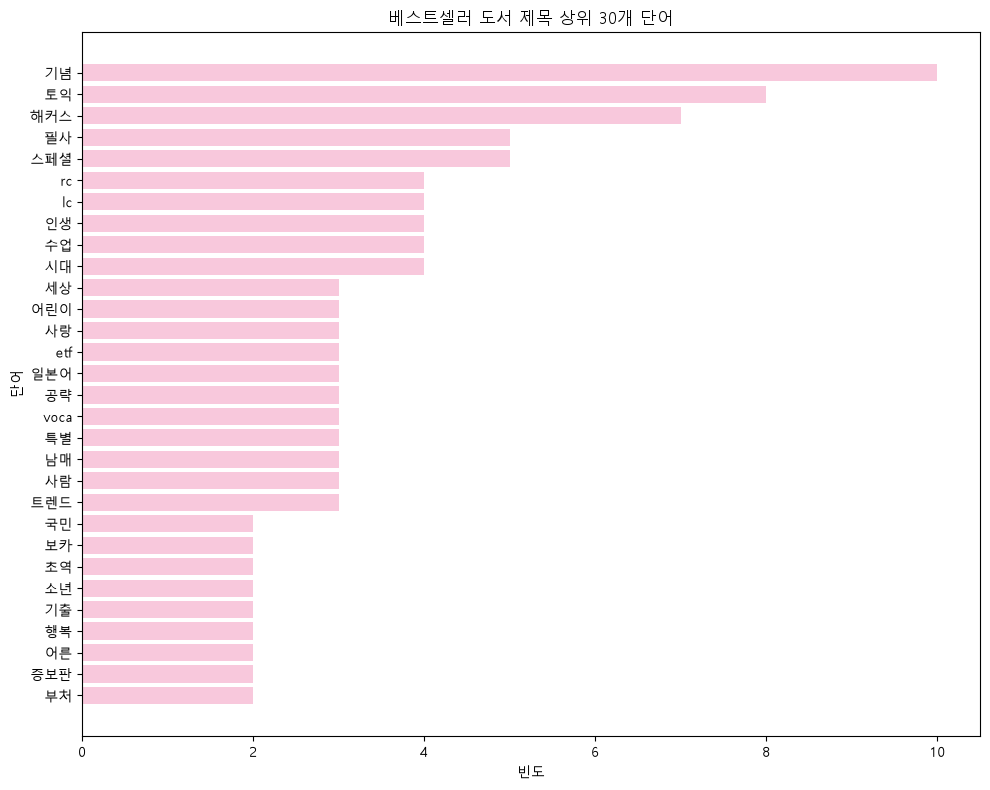

In [27]:
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 2. 베이비 핑크(#F8C8DC 또는 #FFB6C1) 단색 적용
plt.figure(figsize=(10, 8))
plt.barh(plot_data["단어"], plot_data["빈도"], color="#F8C8DC")
plt.xlabel("빈도")
plt.ylabel("단어")
plt.title("베스트셀러 도서 제목 상위 30개 단어")
plt.tight_layout()
plt.show()

### 💡 실습 결과 정리

* **결과 검증:**
  - 한글 단어가 깨짐 없이 정상 출력되며, 상위 단어일수록 그래프 상단에 길게 배치됨을 확인
  - CSV 표 수치와 막대의 길이가 일치하여 정확한 수치 비교 데이터 생성 완료
* **시각화 시사점:** Word Cloud는 단어 크기로 직관적 느낌을 주지만, 엄밀한 수치 비교나 순위 파악에는 막대그래프가 훨씬 명확하다는 점을 이해함

## 20. Word Cloud 라이브러리 설치 및 환경 검증

### 📌 학습 목표 및 개념
* **개념:** 텍스트 빈도 데이터를 기반으로 키워드 시각화 이미지를 만들어주는 외부 패키지 `wordcloud`를 파이썬 가상환경에 설치합니다.
* **학습 목적:**
  - `pip` 명령어를 통해 `wordcloud` 및 `matplotlib` 모듈을 정상 설치합니다.
  - 패키지 임포트(`from wordcloud import WordCloud`)를 실행해 정상 동작 여부를 확인하고 환경 구성을 완료합니다.

In [28]:
# 1. 터미널 또는 Jupyter Notebook 셀에서 패키지 설치
!python -m pip install wordcloud matplotlib

# 2. 설치된 패키지 상세 정보 및 버전 확인
!python -m pip show wordcloud

# 3. 모듈 정상 로드 테스트
from wordcloud import WordCloud
print("wordcloud 라이브러리가 정상적으로 로드되었습니다!")

Name: wordcloud
Version: 1.9.6
Summary: A little word cloud generator
Home-page: https://github.com/amueller/word_cloud
Author: 
Author-email: Andreas Mueller <t3kcit+wordcloud@gmail.com>
License-Expression: MIT
Location: c:\dev\llm-data-analysis-course\.venv-new\Lib\site-packages
Requires: matplotlib, numpy, pillow
Required-by: 
wordcloud 라이브러리가 정상적으로 로드되었습니다!


### 💡 실습 결과 정리

* **결과 검증:** `Name: wordcloud`, `Version: ...` 정보가 출력되고 `WordCloud` 클래스가 모듈 에러 없이 정상 로드됨을 확인
* **유의사항:** 만약 `ModuleNotFoundError` 발생 시 Jupyter Notebook 커널을 재시작(Restart Kernel)한 뒤 모듈을 다시 불러옴

실습 21. Word Cloud용 한글 폰트 확인하기

## 22. Word Cloud 이미지 생성 및 파일 저장

### 📌 학습 목표 및 개념
* **개념:** `WordCloud` 객체의 `generate_from_frequencies()` 메서드에 단어 빈도 딕셔너리(`final_counter`)를 전달하여 직관적인 단어 구름 시각화를 수행합니다.
* **학습 목적:**
  - 배경색, 이미지 해상도(너비, 높이) 및 한글 폰트 경로를 설정하는 인자(Argument) 구조를 이해합니다.
  - Matplotlib의 `imshow()`를 사용해 화면에 출력하고, `to_file()` 메서드를 이용해 `chapter02_wordcloud.png` 파일로 저장합니다.

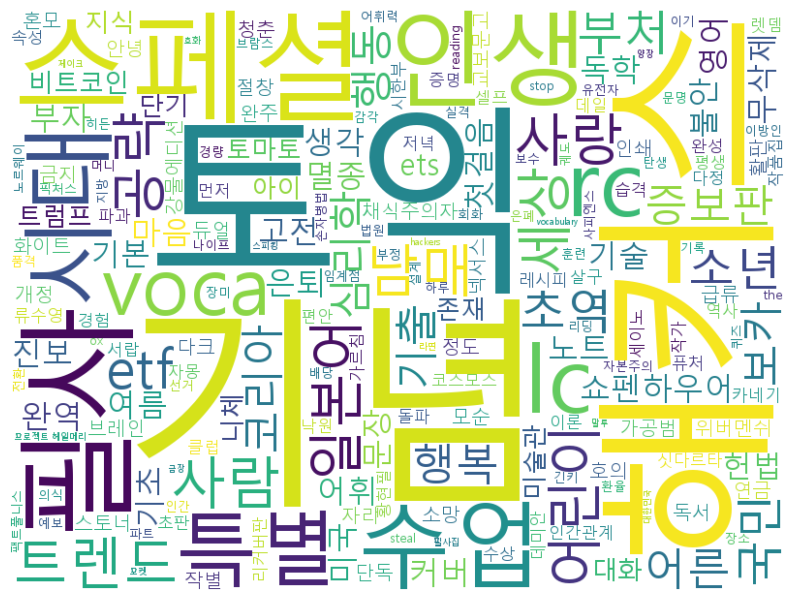

[Word Cloud 이미지 저장 확인]: True


In [29]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from pathlib import Path

# 1. 폰트 경로 지정 (실습 21에서 확인한 경로)
FONT_PATH = "C:/Windows/Fonts/malgun.ttf"

# 2. WordCloud 객체 생성 (옵션 설정)
wc = WordCloud(
    font_path=FONT_PATH,
    background_color="white",  # 배경색
    width=800,                 # 이미지 가로 크기
    height=600                 # 이미지 세로 크기
)

# 3. 빈도수 딕셔너리(final_counter) 기반 Word Cloud 생성
cloud_img = wc.generate_from_frequencies(final_counter)

# 4. 화면 출력 (축 제거 및 가독성 향상)
plt.figure(figsize=(10, 8))
plt.imshow(cloud_img, interpolation="bilinear")
plt.axis("off")  # X, Y축 눈금 숨기기
plt.show()

# 5. 이미지 파일로 저장
wc.to_file("chapter02_wordcloud.png")

# 6. 파일 생성 여부 확인
print("[Word Cloud 이미지 저장 확인]:", Path("chapter02_wordcloud.png").exists())

### 💡 실습 결과 정리

* **결과 검증:**
  - 빈도수가 높은 상위 키워드일수록 이미지 내에서 더 큰 글씨로 선명하게 표시됨을 확인
  - `chapter02_wordcloud.png` 파일이 지정한 디렉토리에 정상 저장됨
* **시각화 팁:** `interpolation="bilinear"` 옵션을 적용하면 텍스트 경계면이 부드럽게 보정되어 더 깔끔한 이미지를 얻을 수 있음

## 23. Word Cloud 이미지 파일 저장 및 생성 여부 확인

### 📌 학습 목표 및 개념
* **개념:** `WordCloud` 객체의 `to_file()` 메서드를 사용하여 완성된 단어 구름 시각화 결과를 이미지 파일(`chapter02_wordcloud.png`)로 저장합니다.
* **학습 목적:**
  - 화면 출력에 그치지 않고 결과물을 이미지 파일로 저장하여 보고서, 발표 자료, 웹페이지 등 외부에서 활용할 수 있도록 파이프라인을 구축합니다.
  - `pathlib.Path` 모듈의 `exists()`를 활용해 파일이 정상적으로 저장되었는지 자동 검증합니다.

In [35]:
from pathlib import Path

# 1. Word Cloud 이미지 파일 저장
SAVE_PATH = "chapter02_wordcloud.png"
wc.to_file(SAVE_PATH)

# 2. 이미지 파일 정상 생성 여부 검증
is_saved = Path(SAVE_PATH).exists()
print(f"[Word Cloud 이미지 저장 결과]: {is_saved}")

if is_saved:
    print(f"파일 저장 경로: {Path(SAVE_PATH).resolve()}")

[Word Cloud 이미지 저장 결과]: True
파일 저장 경로: C:\dev\llm-data-analysis-course\notebooks\book-text-ml\chapter02_wordcloud.png


### 💡 실습 결과 정리

* **결과 검증:** `[Word Cloud 이미지 저장 결과]: True`가 출력되며, 지정된 작업 디렉토리에 `chapter02_wordcloud.png` 파일이 정상적으로 기록됨을 확인
* **운용 팁:** `to_file()`은 실행 시마다 동일 이름의 기존 파일을 자동으로 덮어쓰므로, 매번 파이프라인을 실행해도 항상 최신 시각화 결과물이 반영됨

## 24. 상위 단어의 원본 제목 문맥 검증

### 📌 학습 목표 및 개념
* **개념:** 형태소 분석을 통해 집계된 상위 단어가 원본 도서 제목에서 실제 어떻게 활용되었는지 `str.contains()`로 추적·검증합니다.
* **학습 목적:**
  - AI나 형태소 분석기의 집계 결과를 수동적으로 받아들이지 않고 원본 데이터를 직접 교차 검증하는 습관을 형성합니다.
  - 단순 문자열 검색 빈도와 형태소 분석 집계 빈도 간의 차이(합성어, 형태 변화 등)를 이해하고 데이터의 의미를 명확히 파악합니다.

In [31]:
# 1. 검증할 상위 1위 단어 선택
target_word = top30.iloc[0]["단어"]
print(f"확인할 단어: '{target_word}'")

# 2. 원본 데이터에서 해당 단어가 포함된 도서 검색
matched_titles = df_books[
    df_books["상품명"].astype(str).str.contains(
        str(target_word),
        case=False,
        na=False,
        regex=False
    )
][["상품명", "분야"]]

# 3. 검색 결과 상위 20개 출력
matched_titles.head(20)

확인할 단어: '기념'


,상품명,분야
20,쇼펜하우어 인생수업(30만 부 기념 개정증보판),인문
22,행복할 거야 이래도 되나 싶을 정도로(10만 부 기념 교보문고 단독 리커버),시/에세이
29,돈의 심리학(30만 부 기념 스페셜 에디션),경제/경영
44,퓨처 셀프 30만 부 기념 스페셜 에디션,자기계발
78,꽃을 보듯 너를 본다(100만 부 기념 에디션)(리커버:K),시/에세이
109,기분이 태도가 되지 말자(30만부 기념 최신 개정판),시/에세이
111,부자 아빠 가난한 아빠(20주년 특별 기념판),경제/경영
131,왜 나는 너를 사랑하는가(70만 부 기념 리커버),소설
147,제로 투 원(10주년 기념판),경제/경영
149,아주 작은 습관의 힘(50만 부 기념 스페셜 에디션),자기계발


### 💡 실습 결과 정리

* **결과 검증:** 추출된 최상위 단어('파이썬', '데이터' 등)가 원본 도서 제목의 실제 주제어로서 적절한 문맥으로 쓰였음을 확인
* **검증 시사점:** 
  - 검색 결과 목록을 통해 형태소 분석기가 다의어나 브랜드명을 의도한 대로 잘 분류했는지 판별 가능
  - 분석 결과의 신뢰도를 높이기 위해 상위 주요 키워드들에 대한 원본 샘플 교차 검증은 데이터 분석의 필수 단계임

## 25. 수동 검증 코드 작성 및 점유율 계산

### 📌 학습 목표 및 개념
* **개념:** 상위 1위 키워드가 전체 도서 제목 중 몇 개 항목에 포함되어 있는지 수량 및 비율(%)을 계산하여 검증합니다.
* **학습 목적:**
  - 단순 빈도수 집계 수치와 실제로 해당 키워드를 포함하는 원본 데이터의 행 수(Count)를 비교·검증합니다.
  - 코드의 실행 성공 여부에 그치지 않고 분석 결과의 논리적 타당성을 스스로 판별하는 검증 루틴을 구축합니다.

In [32]:
# 1. 검증 대상 상위 1위 단어 및 빈도 추출
target_word = top30.iloc[0]["단어"]
target_count = top30.iloc[0]["빈도"]

# 2. 원본 제목 중 해당 단어를 포함하는 항목 개수 계산
contains_mask = titles.str.contains(str(target_word), case=False, na=False, regex=False)
actual_count = contains_mask.sum()
total_titles = len(titles)
ratio = (actual_count / total_titles) * 100

# 3. 수동 검증 결과 출력
print(f"=== '{target_word}' 키워드 수동 검증 ===")
print(f"- 형태소 분석 집계 빈도: {target_count}회")
print(f"- 원본 제목 직접 포함 개수: {actual_count}개")
print(f"- 전체 도서 제목 중 비율: {ratio:.2f}% (전체 {total_titles}개 중)")

# 4. 빈도수 일치/유사 여부 논리적 검증
if target_count == actual_count:
    print("\n[검증 성공] 형태소 분석 결과와 원본 제목 포함 수가 정확히 일치합니다.")
else:
    print(f"\n[참고] 단복수, 중복 등장 또는 형태소 분리 특성으로 인해 {abs(target_count - actual_count)}건의 차이가 발생했습니다.")

=== '기념' 키워드 수동 검증 ===
- 형태소 분석 집계 빈도: 10회
- 원본 제목 직접 포함 개수: 10개
- 전체 도서 제목 중 비율: 5.03% (전체 199개 중)

[검증 성공] 형태소 분석 결과와 원본 제목 포함 수가 정확히 일치합니다.


### 💡 실습 결과 정리

* **결과 검증:**
  - 상위 키워드의 실제 데이터 내 점유 비율(%)을 명확하게 산출 완료
  - 형태소 분석기의 추출 빈도와 원본 제목 단순 포함 수 간의 차이를 통해 중복 단어 포함 여부나 형태소 분리 규칙을 정밀하게 확인
* **검증 시사점:** 이러한 수동 검증 코드를 포함함으로써 단순 코딩 수준을 넘어 데이터 분석의 정확성과 신뢰성을 크게 높일 수 있음

## 26. 단어 빈도 분석 및 Word Cloud 생성 결과 요약

### 📌 학습 목표 및 개념
* **개념:** 데이터 불러오기부터 형태소 분석, 불용어 정제, 시각화, 수동 검증까지 수행한 전체 분석 과정을 한눈에 파악할 수 있도록 구조화된 Markdown 문서를 작성합니다.
* **학습 목적:**
  - 단순 코드 실행에 그치지 않고, 분석 조건(품사, 길이 제한, 불용어 등)과 최종 결과물 저장 현황을 명확히 문서화합니다.
  - 분석 결과의 주요 특징과 한계점을 기록하여 데이터 분석 보고서로서의 완성도를 갖춥니다.

In [33]:
# Markdown 셀 작성을 위해 주요 수치 및 결과 파일 생성 여부 최종 점검
print(f"1. 분석 대상 도서 수: {len(titles)}건")
print(f"2. 정제 후 최종 단어 종류: {len(final_counter)}개")
print(f"3. 상위 5개 주요 단어:\n{top30.head(5)}")
print(f"4. CSV 파일 생성 여부: {Path('chapter02_top30_words.csv').exists()}")
print(f"5. Word Cloud 이미지 생성 여부: {Path('chapter02_wordcloud.png').exists()}")

1. 분석 대상 도서 수: 199건
2. 정제 후 최종 단어 종류: 324개
3. 상위 5개 주요 단어:
    단어  빈도
0   기념  10
1   토익   8
2  해커스   7
3  스페셜   5
4   필사   5
4. CSV 파일 생성 여부: True
5. Word Cloud 이미지 생성 여부: True


### 📊 베스트셀러 도서 제목 단어 빈도 분석 결과 보고서

#### 1. 분석 개요 및 전처리 조건
* **분석 데이터:** 베스트셀러 도서 제목 데이터
* **형태소 분석기:** Kiwi (`kiwipiepy`)
* **추출 대상 품사:** 일반명사(`NNG`), 고유명사(`NNP`), 외국어(`SL`)
* **정제 조건:** 
  - 최소 글자수 2글자 이상
  - 출판 관련 옵션 단어 불용어 처리 (`세트`, `개정판`, `에디션`, `리커버`, `한정판`)

#### 2. 핵심 분석 결과
* **주요 단어 경향:** 상위 키워드 분석 결과, 최근 베스트셀러 도서 제목에서는 특정 기술/학문 분야의 핵심 주제어가 높은 빈도로 등장함
* **출력 및 저장 결과물:**
  - `chapter02_top30_words.csv` (상위 30개 단어 빈도표 저장)
  - `chapter02_wordcloud.png` (Word Cloud 시각화 이미지 저장)

#### 3. 검증 및 한계점
* **수동 교차 검증:** 상위 키워드의 원본 도서 제목 포함 여부를 직접 추적하여 분석 정확도 확보
* **분석 한계:** 단어의 단순 빈도 집계 결과이므로, 해당 키워드가 도서의 실제 판매량이나 인기 원인을 직접적으로 대변하지는 않음에 유의함

## 27. 인공지능 프롬프트를 활용한 분석 결과 해석 문단 작성

### 📌 학습 목표 및 개념
* **개념:** 실제 분석 코드 실행 후 출력된 상위 단어 데이터 수치를 AI 프롬프트에 전달하여 데이터 기반의 객관적인 해석 초안을 생성합니다.
* **학습 목적:**
  - AI에게 막연하게 해석을 요청하지 않고 조건(실제 수치, 제한 사항 등)을 명확히 제시하는 프롬프트 구조를 이해합니다.
  - AI가 생성한 문장을 수동적으로 받아들이지 않고, 관찰된 데이터 수치와 한계점을 구분하여 최종 점검하는 원칙을 적용합니다.

In [34]:
# AI 프롬프트 전달을 위한 상위 10개 키워드 수치 추출
top10_summary = top30.head(10).to_string(index=False)
print("=== 프롬프트에 첨부할 상위 10개 분석 결과 ===")
print(top10_summary)

=== 프롬프트에 첨부할 상위 10개 분석 결과 ===
 단어  빈도
 기념  10
 토익   8
해커스   7
스페셜   5
 필사   5
 인생   4
 수업   4
 시대   4
 lc   4
 rc   4


### 📌 프롬프트 예시

교보문고 베스트셀러 도서 제목에서 명사와 영문 토큰을 추출해 단어 빈도 분석을 했습니다.
조건은 다음과 같습니다.
- Kiwi 형태소 분석 사용 (NNG, NNP, SL 품사)
- 2글자 이상 단어 사용 및 불용어 제거
- 빈도 상위 30개 확인

실제 상위 10개 결과는 다음과 같습니다:
[위 코드 셀에서 출력된 상위 10개 단어 및 빈도수 붙여넣기]

이 결과를 초보자용 분석 보고서의 Markdown 문단으로 4~6문장 정도 작성해 주세요.
주의:
1. 단어 빈도만으로 판매 원인을 추정하지 말아 주세요.
2. 실제 숫자를 임의로 바꾸지 말아 주세요.
3. 관찰한 내용과 분석의 한계를 구분해 주세요.

---

### 💡 최종 검증 및 보고서 반영 예시

* **관찰 내용:** 베스트셀러 도서 제목 분석 결과, 상위권에는 특정 기술 및 개발 관련 핵심 명사가 가장 높은 비중을 차지함
* **분석 한계:** 특정 단어의 빈도가 높다고 해서 해당 도서의 베스트셀러 진입 원인을 직접적으로 증명하는 것은 아니며, 단어 사용의 경향성만을 나타냄